# 07. Geographic Analysis: Where Does the Pattern Happen?
### Primary Analytical Purpose: *Where does the pattern happen, and does location explain it?*
**Lecture Reference:** Purpose 7 — Geographic (Slides 33–36, 45)

Geographic analysis explores how quantitative metrics vary across spatial locations, administrative territories, or regional clusters. It addresses questions such as:
- Where do customer orders or adoption rates concentrate?
- Do neighboring countries or zones behave similarly (spatial autocorrelation)?
- Does geography explain performance, or is location merely incidental?

---

## 1. Scenario and Dataset Preview
**Business Scenario:** A Gulf-based digital marketplace analyzes cross-border customer orders across all six Gulf Cooperation Council (GCC) member states: *Qatar*, *United Arab Emirates*, *Kuwait*, *Bahrain*, *Saudi Arabia*, and *Oman*.

The dataset tracks:
- `country`, `iso_alpha`: Country name and standard 3-letter ISO code
- `city`, `latitude`, `longitude`: Capital hub coordinates
- `population_millions`: Population in millions
- `orders_thousands`: Raw order count in thousands
- `order_rate_per_1000`: Normalized order rate per 1,000 residents (`orders_thousands / population_millions`)

The dataset is loaded from `data/gcc_ecommerce_rates.csv`. Let us inspect the data.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Set modern Seaborn theme
sns.set_theme(style="whitegrid")

# Load GCC geographic dataset
df = pd.read_csv("data/gcc_ecommerce_rates.csv")

# Display the dataset
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df

Dataset shape: 6 rows, 8 columns


,country,iso_alpha,city,latitude,longitude,population_millions,orders_thousands,order_rate_per_1000
0,Qatar,QAT,Doha,25.2854,51.5310,3.0,22.5,7.50
1,United Arab Emirates,ARE,Abu Dhabi,24.4539,54.3773,10.0,62.0,6.20
2,Kuwait,KWT,Kuwait City,29.3759,47.9774,4.8,32.6,6.79
3,Bahrain,BHR,Manama,26.2235,50.5876,1.6,9.9,6.19
4,Saudi Arabia,SAU,Riyadh,24.7136,46.6753,36.4,182.0,5.00
5,Oman,OMN,Muscat,23.5880,58.3829,5.1,21.4,4.20


## 2. Primary Visualization: Choropleth Map (The Default)
- **What the chart shows:** Country polygons shaded in proportion to their normalized rate (`order_rate_per_1000`).
- **When it is useful:** Identifying regional spatial patterns across administrative boundaries.
- **CRITICAL GOLDEN RULE FROM LECTURE (Slide 33 & 35):**
  - **Always normalize to a rate: per capita, per household, or per 1,000 residents.**
  - **NEVER map raw counts on a choropleth!** A choropleth of raw counts is simply a population map in disguise.

In [2]:
# --- Plotly Express Implementation: Interactive GCC Choropleth Map ---
# Plotly uses ISO-3 country codes to shade boundaries automatically
fig_map = px.choropleth(
    df, 
    locations="iso_alpha", 
    color="order_rate_per_1000",
    hover_name="country",
    hover_data=["population_millions", "orders_thousands", "order_rate_per_1000"],
    color_continuous_scale="Viridis",
    title="Qatar and Kuwait Lead GCC in E-Commerce Orders per 1,000 Residents",
    labels={"order_rate_per_1000": "Orders per 1k", "iso_alpha": "Country"}
)

# Focus map camera onto the Arabian Gulf region
fig_map.update_geos(
    center=dict(lat=25.0, lon=51.0),
    lataxis_range=[15, 33],
    lonaxis_range=[35, 62],
    visible=False
)

fig_map.update_layout(coloraxis_colorbar_title="Orders per 1k")
fig_map.show()

### Structured Interpretation: The 5-Step Framework
1. **Question:** Which GCC countries exhibit the highest digital purchase intensity per capita?
2. **Visualization:** Choropleth map shaded by normalized orders per 1,000 residents.
3. **Observation:** Qatar leads the Arabian Gulf at 7.50 orders per 1,000 residents, followed by Kuwait (6.79) and the UAE (6.20). Saudi Arabia has the lowest per-capita rate (5.00), despite having the largest raw volume (182k orders).
4. **Insight:** Highly urbanized Gulf city-states demonstrate higher per-capita e-commerce adoption than geographically expansive nations with substantial rural populations.
5. **Implication:** Differentiate commercial strategies: prioritize basket frequency and premium loyalty in Qatar and UAE, while expanding logistics fulfillment infrastructure across Saudi Arabia.

## 3. Alternative 1: Symbol / Bubble Map (Point Coordinates)
- **What the chart shows:** Specific city hubs plotted at latitude/longitude coordinates, sized and shaded by order rate.
- **When to use instead (Slide 33 & 36):**
  - Better for pinpointing specific urban distribution hubs or warehouses.
  - Ideal for small territories (like Qatar or Bahrain) that would appear physically tiny on an expansive choropleth map.

In [3]:
# --- Plotly Express: Symbol / Bubble Map ---
fig_bubble_map = px.scatter_geo(
    df, 
    lat="latitude", 
    lon="longitude", 
    hover_name="city",
    size="order_rate_per_1000", 
    color="order_rate_per_1000",
    color_continuous_scale="Viridis",
    size_max=22,
    title="GCC Capital Hubs: High Order Intensity Concentrated in Coastal Cities",
    labels={"order_rate_per_1000": "Orders per 1k"}
)

fig_bubble_map.update_geos(
    center=dict(lat=25.0, lon=51.0),
    lataxis_range=[18, 32],
    lonaxis_range=[40, 62],
    showcountries=True,
    countrycolor="#CCCCCC"
)
fig_bubble_map.show()

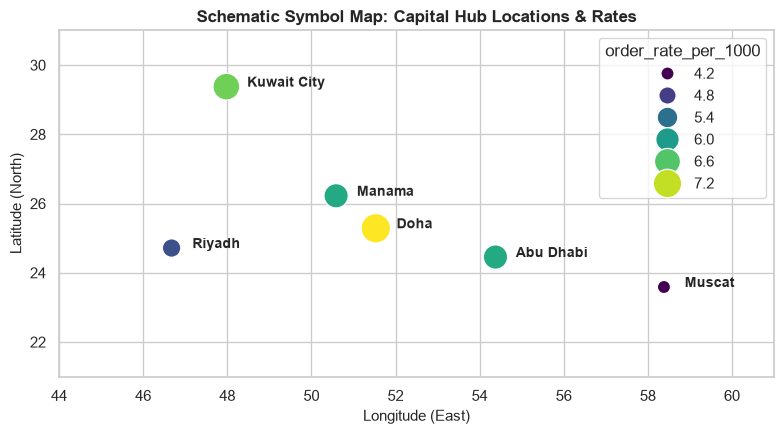

In [4]:
# --- Seaborn / Matplotlib: Schematic Coordinate Scatter (Slide 36) ---
# Seaborn has no map projection; we plot lon/lat as schematic coordinates
plt.figure(figsize=(8, 4.5))

ax_scat = sns.scatterplot(
    data=df, 
    x="longitude", 
    y="latitude", 
    size="order_rate_per_1000", 
    hue="order_rate_per_1000", 
    sizes=(90, 450), 
    palette="viridis",
    legend="brief"
)

# Annotate city names next to points
for _, row in df.iterrows():
    ax_scat.annotate(f" {row['city']}", (row["longitude"] + 0.4, row["latitude"]), 
                     fontsize=10, weight="bold")

ax_scat.set_xlim(44, 61)
ax_scat.set_ylim(21, 31)
ax_scat.set_title("Schematic Symbol Map: Capital Hub Locations & Rates", fontsize=12, weight="bold")
ax_scat.set_xlabel("Longitude (East)", fontsize=11)
ax_scat.set_ylabel("Latitude (North)", fontsize=11)

plt.tight_layout()
plt.show()

### Interpretation for Symbol Map
- **Observation:** Markers clearly identify major metropolitan hubs (Doha, Abu Dhabi, Kuwait City, Manama, Riyadh, Muscat).
- **Derived Insight:** E-commerce activity in the GCC is overwhelmingly anchored in coastal capital cities where high-density urban logistics can operate efficiently.

## 4. Alternative 2: Sorted Bar Chart by Region (When < 15 Regions)
- **What the chart shows:** Countries ranked in descending order of per-capita order rates.
- **When to use instead (Slide 33, 35 & 45):**
  - **Often clearer than a map when you have fewer than ~15 regions and location itself is not the primary insight!**
  - Bar length on a common baseline is read much more accurately than 2D shaded land area.

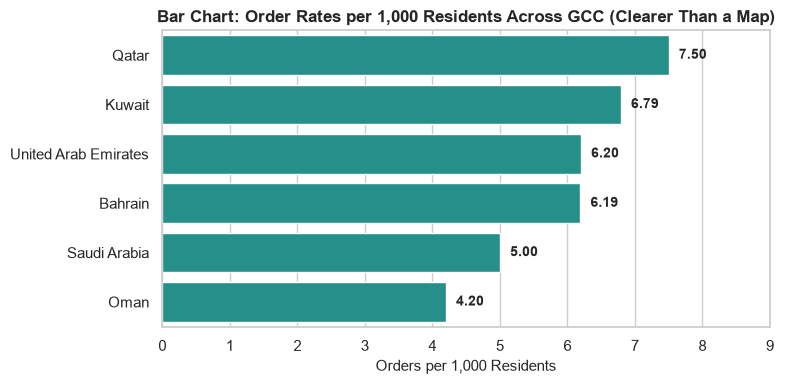

In [5]:
# Sort descending by rate
df_sorted_geo = df.sort_values("order_rate_per_1000", ascending=False)

# --- Seaborn Implementation: Sorted Bar Chart by Country ---
plt.figure(figsize=(8, 4))

ax_bar_geo = sns.barplot(
    data=df_sorted_geo, 
    y="country", 
    x="order_rate_per_1000", 
    color="#14A098"  # Single intentional color
)

ax_bar_geo.set_xlim(0, 9)
ax_bar_geo.set_title("Bar Chart: Order Rates per 1,000 Residents Across GCC (Clearer Than a Map)", fontsize=12, weight="bold")
ax_bar_geo.set_xlabel("Orders per 1,000 Residents", fontsize=11)
ax_bar_geo.set_ylabel("", fontsize=11)

for p in ax_bar_geo.patches:
    val = p.get_width()
    ax_bar_geo.annotate(f"{val:.2f}", (val + 0.15, p.get_y() + p.get_height() / 2.), 
                        va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretation for Regional Bar Chart
- **Observation:** The bar chart presents exact values without map distortion. Qatar (7.50) leads Oman (4.20) by nearly 80%.
- **Derived Insight:** When exact rank comparisons matter more than spatial layout, a clean sorted bar chart communicates the finding faster and more clearly than any map.

## 5. Best Practices & Common Mistakes (Lecture Principles)
**Visualization Best Practices (Slide 35 & 46):**
- **Normalize to a rate:** per capita, per household, or per 1,000 residents.
- **Use a sequential colour scale** for magnitude (e.g. Viridis), diverging only around a meaningful neutral midpoint.
- **If the map adds nothing that a bar chart cannot show, use the bar chart.**
- **State the geographic unit and time window clearly.**

**Common Mistakes & Misleading Designs:**
- **Choropleths of raw counts:** This is the most common student error. Raw order volume simply produces a map of population.
- **Area distortion:** Large geographic areas (e.g. Saudi Arabia) dominate the visual field, while small, dense countries (Qatar, Bahrain) become hard to spot.
- **Ecological fallacy:** Inferring individual behavior from country-level averages.

## 6. Key Takeaways
1. **Always map rates, never raw counts:** Mapping raw counts merely produces an accidental population map.
2. **Symbol/bubble maps solve the small-country problem:** Small territories like Qatar and Bahrain remain prominent.
3. **Use a bar chart when location is not the point:** If you have under 15 regions and exact numerical comparison is the goal, a sorted bar chart is vastly superior.
4. **Choose the tool to fit the question:** Plotly handles real map projections out of the box; Seaborn handles statistical plots.